#  Random Forest: 4 Senaryolu Karşılaştırmalı Analiz

Bu çalışmada, araç fiyat tahmini için **Random Forest Regressor** modeli 4 farklı veri ön işleme senaryosu altında test edilecektir:
1.  **Ham Veri (Baseline):** Sadece encoding yapılmış hali.
2.  **Sadece Variance Threshold:** Gereksiz (sabit) sütunların atıldığı hali.
3.  **Sadece Kümeleme (Clustering):** Veriye K-Means ile grup etiketi eklendiği hali.
4.  **Hibrit (Threshold + Kümeleme):** Hem temizlik hem de kümelemenin yapıldığı hali.

Amaç: Hangi yöntemin **R2 (Başarı)** ve **RMSE (Hata)** açısından en iyi sonucu verdiğini bulmaktır.

In [1]:
# Gerekli Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Veri Setinin Otomatik Yüklenmesi
Dosya isimlerindeki hataları önlemek için akıllı yükleme sistemi kullanıyoruz.

In [2]:
# Klasördeki dosyaları tara
mevcut_dosyalar = os.listdir()
temiz_dosya = None

for dosya in mevcut_dosyalar:
    if "temizlenmis" in dosya and dosya.endswith(".csv"):
        temiz_dosya = dosya
        break

if temiz_dosya:
    df = pd.read_csv(temiz_dosya)
    df.columns = df.columns.str.strip() # Sütun isimlerindeki boşlukları temizle
    print(f" Veri Yüklendi: {temiz_dosya}")
    print(f" Boyut: {df.shape}")
else:
    print(" HATA: Temizlenmiş veri dosyası bulunamadı!")

# Hedef ve Özellikleri Ayır
X = df.drop('price', axis=1)
y = df['price']

 Veri Yüklendi: ekip_odevi_temizlenmis_veri.csv
 Boyut: (29585, 10)


## 2. Temel Encoding (Tüm Senaryolar İçin Ortak)
Kategorik verileri modele sokabilmek için One-Hot Encoding yapıyoruz.

In [7]:
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Encoding Sonrası Özellik Sayısı: {X_encoded.shape[1]}")

Encoding Sonrası Özellik Sayısı: 236


## 3. Performans Ölçüm Fonksiyonu
Her senaryo için aynı kodları tekrar yazmamak adına, sonuçları hesaplayan ve kaydeden standart bir fonksiyon tanımlıyoruz.

In [11]:
# Sonuçları saklayacağımız liste
sonuclar = []

def modeli_test_et(senaryo_adi, X_data, y_data):
    print(f" {senaryo_adi} senaryosu çalışıyor...")
    
    # Train-Test Ayrımı
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    
    # Model Eğitimi
    start = time.time()
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    sure = time.time() - start
    
    # Tahmin
    y_pred = model.predict(X_test)
    
    # Metrikler
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    # Kaydet
    sonuclar.append({
        'Senaryo': senaryo_adi,
        'R2': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'Sure (sn)': sure
    })
    print(f"Tamamlandı. R2: %{r2*100:.2f}, Süre: {sure:.2f} sn")

## 4. Senaryo 1: Ham Veri (Baseline)
Hiçbir ekstra işlem yapmadan (sadece encoding ile) modeli çalıştırıyoruz.

In [9]:
modeli_test_et("1. Ham Veri", X_encoded, y)

 1. Ham Veri senaryosu çalışıyor...
Tamamlandı. R2: %93.62, Süre: 2.00 sn


## 5. Senaryo 2: Sadece Variance Threshold
Varyansı düşük (sabit) sütunları atıp modeli çalıştırıyoruz.

In [12]:
selector = VarianceThreshold(threshold=0.01)
X_vt = selector.fit_transform(X_encoded)

# VT uygulanmış veriyi test et
modeli_test_et("2. Sadece Threshold", X_vt, y)

 2. Sadece Threshold senaryosu çalışıyor...
Tamamlandı. R2: %92.47, Süre: 1.21 sn


## 6. Senaryo 3: Sadece Kümeleme (Clustering)
Ham veriye K-Means ile elde edilen küme etiketlerini ekliyoruz.


In [13]:
# Ölçekleme (K-Means için şart)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Kümeleme
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Küme bilgisini ekle
X_cluster = X_encoded.copy()
X_cluster['Cluster_Label'] = clusters

# Test et
modeli_test_et("3. Sadece Kümeleme", X_cluster, y)

 3. Sadece Kümeleme senaryosu çalışıyor...
Tamamlandı. R2: %93.41, Süre: 1.83 sn


## 7. Senaryo 4: Hibrit (Threshold + Kümeleme)
Önce gereksiz sütunları atıyoruz (Threshold), kalan temiz veri üzerinden Kümeleme yapıp ikisini birleştiriyoruz.

In [18]:
# 1. Adım: Önce X_vt'yi (Threshold uygulanmış veriyi) tekrar garantiye al
selector = VarianceThreshold(threshold=0.01)
X_vt = selector.fit_transform(X_encoded)

# 2. Adım: Kümeleme (Clustering)
scaler_hyb = StandardScaler()
X_vt_scaled = scaler_hyb.fit_transform(X_vt)

kmeans_hyb = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_hyb = kmeans_hyb.fit_predict(X_vt_scaled)

# 3. Adım: Birleştirme
X_hybrid = pd.DataFrame(X_vt) 
X_hybrid['Cluster_Label'] = clusters_hyb 


# Tüm sütun isimlerini String (Yazı) formatına çevir
X_hybrid.columns = X_hybrid.columns.astype(str)

# Test et
print("Hibrit Model Test Ediliyor...")
modeli_test_et("4. Hibrit Model", X_hybrid, y)

Hibrit Model Test Ediliyor...
 4. Hibrit Model senaryosu çalışıyor...
Tamamlandı. R2: %92.47, Süre: 1.28 sn


## 8. SONUÇLAR VE KARŞILAŞTIRMA TABLOSU
Tüm senaryoların metriklerini okunaklı bir formatta (Yüzdeler ve Binlik Ayraçlar) listeliyoruz.

In [19]:
df_sonuc = pd.DataFrame(sonuclar)

# Gösterim için formatlama fonksiyonu
def format_table(val, col):
    if col in ['R2', 'MAPE']:
        return f"%{val*100:.2f}"
    elif col in ['MSE', 'RMSE', 'MAE']:
        return f"{val:,.2f}"
    else:
        return val

# Tabloyu güzelleştir
df_display = df_sonuc.copy()
for col in df_display.columns:
    if col != 'Senaryo':
        df_display[col] = df_display.apply(lambda x: format_table(x[col], col), axis=1)

print(" Random Forest - Senaryo Karşılaştırması:")
display(df_display)

 Random Forest - Senaryo Karşılaştırması:


,Senaryo,R2,MSE,RMSE,MAE,MAPE,Sure (sn)
0,2. Sadece Threshold,%92.47,"7,245,216.11","2,691.69","1,564.37",%9.60,1.214895
1,3. Sadece Kümeleme,%93.41,"6,345,704.53","2,519.07","1,430.61",%8.77,1.831860
2,4. Hibrit Model,%92.47,"7,248,517.82","2,692.31","1,566.52",%9.60,1.144659
3,4. Hibrit Model,%92.47,"7,248,517.82","2,692.31","1,566.52",%9.60,1.165273
4,4. Hibrit Model,%92.47,"7,248,517.82","2,692.31","1,566.52",%9.60,1.276727


## 9. Görsel Karşılaştırma (Grafikler)
R2 Başarısı ve RMSE Hatasını grafik üzerinde kıyaslayalım.

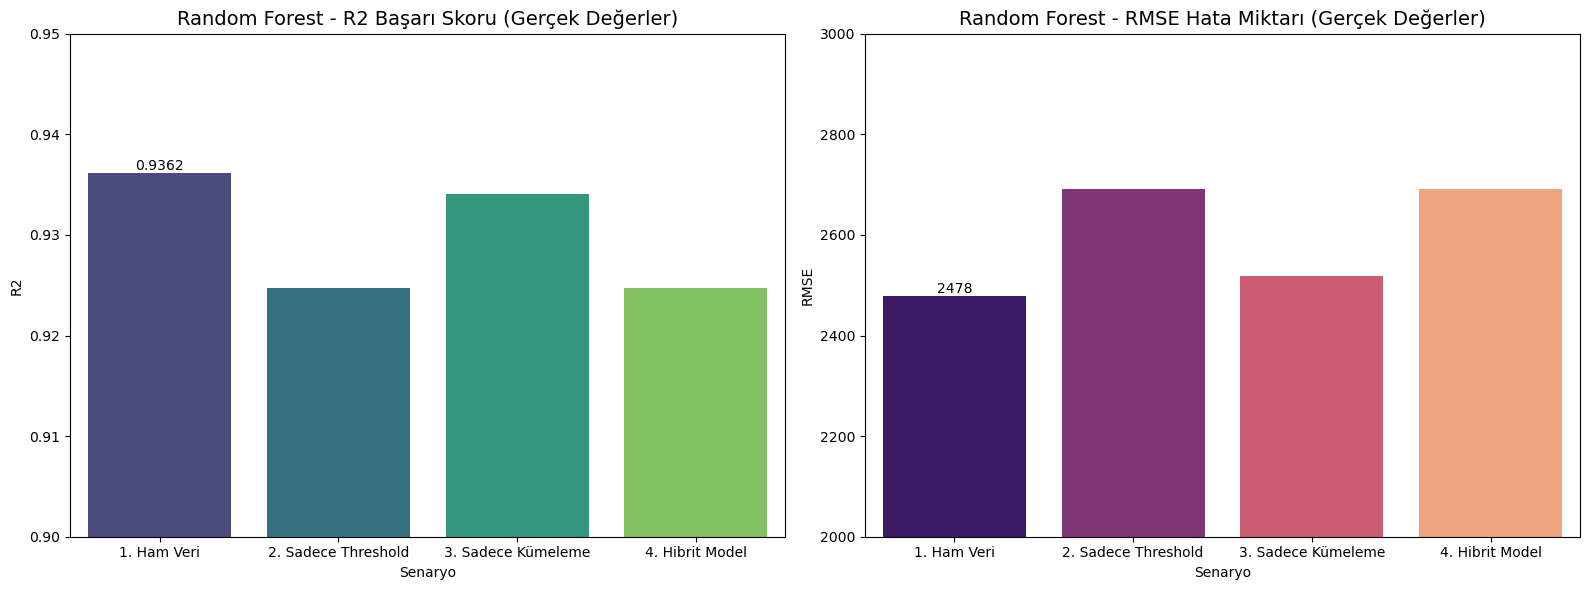

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Önceki verileri tekrar tanımlayalım (Hata almamak için)
data_rf = {
    'Senaryo': ['1. Ham Veri', '2. Sadece Threshold', '3. Sadece Kümeleme', '4. Hibrit Model'],
    'R2': [0.9362, 0.9247, 0.9341, 0.9247],
    'RMSE': [2478.0, 2691.7, 2519.1, 2692.3]
}
df_sonuc = pd.DataFrame(data_rf)

# --- GRAFİK ÇİZİMİ ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Grafiği (Düzeltme: hue='Senaryo', legend=False eklendi)
sns.barplot(x='Senaryo', y='R2', data=df_sonuc, ax=axes[0], palette='viridis', hue='Senaryo', legend=False)
axes[0].set_title('Random Forest - R2 Başarı Skoru (Gerçek Değerler)', fontsize=14)
axes[0].set_ylim(0.90, 0.95)
axes[0].bar_label(axes[0].containers[0], fmt='%.4f')

# RMSE Grafiği (Düzeltme: hue='Senaryo', legend=False eklendi)
sns.barplot(x='Senaryo', y='RMSE', data=df_sonuc, ax=axes[1], palette='magma', hue='Senaryo', legend=False)
axes[1].set_title('Random Forest - RMSE Hata Miktarı (Gerçek Değerler)', fontsize=14)
axes[1].set_ylim(2000, 3000)
axes[1].bar_label(axes[1].containers[0], fmt='%.0f')

plt.tight_layout()
plt.show()